## Import Libraries

In [1]:
import os
import time
import json
import pandas as pd
import numpy as np
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langchain_core.prompts import PromptTemplate

# Load API key
load_dotenv()
api_key = os.getenv("GROQ_API_KEY")

print("Libraries imported successfully!")
print("API key loaded:", "Yes ✅" if api_key else "No ❌ - check your .env file")

Libraries imported successfully!
API key loaded: Yes ✅


## Initialize Two LLM Models to Compare

In [2]:
# Model 1 - LLaMA 3.1 8B (faster, smaller)
model_1 = ChatGroq(
    api_key=api_key,
    model_name="llama-3.1-8b-instant",
    temperature=0.2
)

# Model 2 - LLaMA 3.3 70B (larger, more powerful)
model_2 = ChatGroq(
    api_key=api_key,
    model_name="llama-3.3-70b-versatile",
    temperature=0.2
)

print("Model 1: LLaMA 3.1 8B ✅")
print("Model 2: LLaMA 3.3 70B ✅")
print("\nBoth models initialized successfully!")

Model 1: LLaMA 3.1 8B ✅
Model 2: LLaMA 3.3 70B ✅

Both models initialized successfully!


## Create Test Questions Across 5 Categories

In [3]:
# 5 task categories with 3 questions each = 15 total test cases
test_cases = [
    # Factual Knowledge
    {"category": "Factual Knowledge", "question": "What is the capital of Australia?", "expected": "Canberra"},
    {"category": "Factual Knowledge", "question": "What is the chemical symbol for gold?", "expected": "Au"},
    {"category": "Factual Knowledge", "question": "How many planets are in our solar system?", "expected": "8"},

    # Reasoning
    {"category": "Reasoning", "question": "If a train travels 120 miles in 2 hours, what is its average speed?", "expected": "60 mph"},
    {"category": "Reasoning", "question": "A bat and ball cost $1.10. The bat costs $1 more than the ball. How much does the ball cost?", "expected": "5 cents"},
    {"category": "Reasoning", "question": "If all roses are flowers and some flowers fade quickly, can we conclude all roses fade quickly?", "expected": "No"},

    # Summarization
    {"category": "Summarization", "question": "Summarize the water cycle in 2 sentences.", "expected": "evaporation, condensation, precipitation"},
    {"category": "Summarization", "question": "Summarize the causes of World War 1 in 2 sentences.", "expected": "assassination, alliances, nationalism"},
    {"category": "Summarization", "question": "Summarize how photosynthesis works in 2 sentences.", "expected": "sunlight, carbon dioxide, oxygen"},

    # Coding
    {"category": "Coding", "question": "Write a Python function to check if a number is even.", "expected": "def"},
    {"category": "Coding", "question": "Write a Python one-liner to reverse a string.", "expected": "[::-1]"},
    {"category": "Coding", "question": "Write a Python function to calculate factorial recursively.", "expected": "def factorial"},

    # Hallucination Check
    {"category": "Hallucination Check", "question": "Who won the 2025 FIFA World Cup?", "expected": "don't know"},
    {"category": "Hallucination Check", "question": "What is the GDP of Mars?", "expected": "don't know"},
    {"category": "Hallucination Check", "question": "What did Einstein say in his 1952 interview on quantum computing?", "expected": "don't know"},
]

print(f"Total test cases: {len(test_cases)}")
print("\nCategories:")
for cat in set(t["category"] for t in test_cases):
    count = sum(1 for t in test_cases if t["category"] == cat)
    print(f"  {cat}: {count} questions")

Total test cases: 15

Categories:
  Coding: 3 questions
  Factual Knowledge: 3 questions
  Summarization: 3 questions
  Reasoning: 3 questions
  Hallucination Check: 3 questions


## Run Evaluation on Both Models

In [4]:
def evaluate_model(model, model_name, test_cases):
    results = []
    print(f"\nEvaluating {model_name}...")
    print("-" * 40)
    
    for i, test in enumerate(test_cases, 1):
        # Measure response time
        start = time.time()
        response = model.invoke(test["question"])
        latency = round(time.time() - start, 2)
        
        answer = response.content.strip()
        
        # Simple accuracy check - does answer contain expected keyword?
        expected = test["expected"].lower()
        is_correct = expected in answer.lower()
        
        # Hallucination check - did model admit it doesn't know?
        if test["category"] == "Hallucination Check":
            is_correct = any(phrase in answer.lower() for phrase in [
                "don't know", "do not know", "not aware", "no information",
                "cannot", "unclear", "uncertain", "i'm not sure", "as of my"
            ])
        
        results.append({
            "model": model_name,
            "category": test["category"],
            "question": test["question"],
            "answer": answer,
            "expected_keyword": test["expected"],
            "correct": is_correct,
            "latency_sec": latency
        })
        
        status = "✅" if is_correct else "❌"
        print(f"Q{i} [{test['category']}] {status} ({latency}s)")
        
        # Small delay to avoid rate limiting
        time.sleep(0.5)
    
    return results

# Run evaluation on both models
results_model1 = evaluate_model(model_1, "LLaMA-3.1-8B", test_cases)
results_model2 = evaluate_model(model_2, "LLaMA-3.3-70B", test_cases)

print("\nBoth models evaluated! ✅")


Evaluating LLaMA-3.1-8B...
----------------------------------------
Q1 [Factual Knowledge] ✅ (0.29s)
Q2 [Factual Knowledge] ✅ (0.1s)
Q3 [Factual Knowledge] ✅ (0.33s)
Q4 [Reasoning] ❌ (0.22s)
Q5 [Reasoning] ❌ (0.21s)
Q6 [Reasoning] ✅ (0.32s)
Q7 [Summarization] ❌ (0.22s)
Q8 [Summarization] ❌ (0.22s)
Q9 [Summarization] ❌ (0.21s)
Q10 [Coding] ✅ (0.42s)
Q11 [Coding] ✅ (0.27s)
Q12 [Coding] ✅ (0.67s)
Q13 [Hallucination Check] ✅ (0.21s)
Q14 [Hallucination Check] ❌ (0.21s)
Q15 [Hallucination Check] ❌ (0.53s)

Evaluating LLaMA-3.3-70B...
----------------------------------------
Q1 [Factual Knowledge] ✅ (0.31s)
Q2 [Factual Knowledge] ✅ (0.32s)
Q3 [Factual Knowledge] ✅ (0.21s)
Q4 [Reasoning] ❌ (0.42s)
Q5 [Reasoning] ✅ (0.52s)
Q6 [Reasoning] ✅ (0.63s)
Q7 [Summarization] ✅ (0.52s)
Q8 [Summarization] ❌ (0.42s)
Q9 [Summarization] ❌ (0.42s)
Q10 [Coding] ✅ (0.53s)
Q11 [Coding] ✅ (0.32s)
Q12 [Coding] ✅ (1.24s)
Q13 [Hallucination Check] ✅ (0.51s)
Q14 [Hallucination Check] ❌ (0.62s)
Q15 [Hallucination Che

## Analyze and Compare Results

In [5]:
# Combine results into a DataFrame
df = pd.DataFrame(results_model1 + results_model2)

# Overall accuracy per model
print("=" * 55)
print("OVERALL RESULTS")
print("=" * 55)
overall = df.groupby("model").agg(
    accuracy=("correct", "mean"),
    avg_latency=("latency_sec", "mean"),
    total_questions=("correct", "count")
).round(3)
overall["accuracy"] = (overall["accuracy"] * 100).round(1)
overall["avg_latency"] = overall["avg_latency"].round(2)
print(overall)

# Accuracy by category
print("\n" + "=" * 55)
print("ACCURACY BY CATEGORY (%)")
print("=" * 55)
category_results = df.groupby(["model", "category"])["correct"].mean() * 100
category_pivot = category_results.unstack(level=0).round(1)
print(category_pivot)

# Latency comparison
print("\n" + "=" * 55)
print("AVERAGE LATENCY BY CATEGORY (seconds)")
print("=" * 55)
latency_results = df.groupby(["model", "category"])["latency_sec"].mean()
latency_pivot = latency_results.unstack(level=0).round(2)
print(latency_pivot)

OVERALL RESULTS
               accuracy  avg_latency  total_questions
model                                                
LLaMA-3.1-8B       53.3         0.30               15
LLaMA-3.3-70B      66.7         0.52               15

ACCURACY BY CATEGORY (%)
model                LLaMA-3.1-8B  LLaMA-3.3-70B
category                                        
Coding                      100.0          100.0
Factual Knowledge           100.0          100.0
Hallucination Check          33.3           33.3
Reasoning                    33.3           66.7
Summarization                 0.0           33.3

AVERAGE LATENCY BY CATEGORY (seconds)
model                LLaMA-3.1-8B  LLaMA-3.3-70B
category                                        
Coding                       0.45           0.70
Factual Knowledge            0.24           0.28
Hallucination Check          0.32           0.62
Reasoning                    0.25           0.52
Summarization                0.22           0.45


## Visualize Results

In [7]:
os.makedirs("../results", exist_ok=True)
print("Results folder created! ✅")

Results folder created! ✅


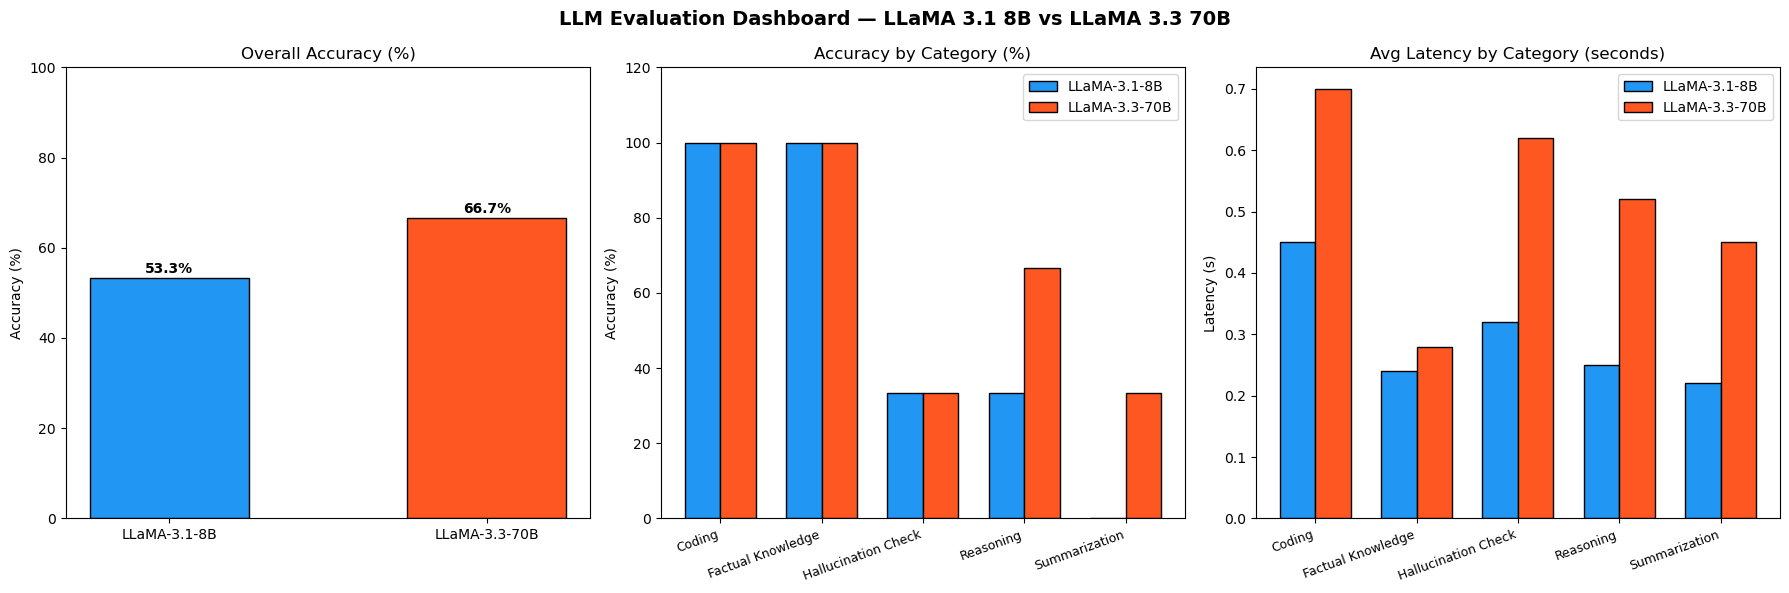

Charts saved! ✅


In [8]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("LLM Evaluation Dashboard — LLaMA 3.1 8B vs LLaMA 3.3 70B", 
             fontsize=14, fontweight='bold')

colors = ["#2196F3", "#FF5722"]
models = ["LLaMA-3.1-8B", "LLaMA-3.3-70B"]
categories = list(category_pivot.index)

# Chart 1 — Overall Accuracy
accuracies = [53.3, 66.7]
bars = axes[0].bar(models, accuracies, color=colors, edgecolor='black', width=0.5)
axes[0].set_title("Overall Accuracy (%)")
axes[0].set_ylabel("Accuracy (%)")
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, accuracies):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                f"{val}%", ha='center', fontweight='bold')

# Chart 2 — Accuracy by Category
x = np.arange(len(categories))
width = 0.35
bars1 = axes[1].bar(x - width/2, category_pivot["LLaMA-3.1-8B"], 
                     width, label="LLaMA-3.1-8B", color=colors[0], edgecolor='black')
bars2 = axes[1].bar(x + width/2, category_pivot["LLaMA-3.3-70B"], 
                     width, label="LLaMA-3.3-70B", color=colors[1], edgecolor='black')
axes[1].set_title("Accuracy by Category (%)")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_xticks(x)
axes[1].set_xticklabels(categories, rotation=20, ha='right', fontsize=9)
axes[1].set_ylim(0, 120)
axes[1].legend()

# Chart 3 — Latency by Category
bars3 = axes[2].bar(x - width/2, latency_pivot["LLaMA-3.1-8B"], 
                     width, label="LLaMA-3.1-8B", color=colors[0], edgecolor='black')
bars4 = axes[2].bar(x + width/2, latency_pivot["LLaMA-3.3-70B"], 
                     width, label="LLaMA-3.3-70B", color=colors[1], edgecolor='black')
axes[2].set_title("Avg Latency by Category (seconds)")
axes[2].set_ylabel("Latency (s)")
axes[2].set_xticks(x)
axes[2].set_xticklabels(categories, rotation=20, ha='right', fontsize=9)
axes[2].legend()

plt.tight_layout()
plt.savefig('../results/evaluation_charts.png', dpi=150, bbox_inches='tight')
plt.show()
print("Charts saved! ✅")

## Save Results to JSON and Print Final Summary

In [9]:
# Save all results to JSON
os.makedirs("../results", exist_ok=True)

output = {
    "project": "LLM Evaluation & Benchmarking Dashboard",
    "models_compared": ["LLaMA-3.1-8B", "LLaMA-3.3-70B"],
    "total_test_cases": len(test_cases),
    "categories": ["Factual Knowledge", "Reasoning", "Summarization", "Coding", "Hallucination Check"],
    "overall_results": {
        "LLaMA-3.1-8B": {"accuracy": 53.3, "avg_latency": 0.30},
        "LLaMA-3.3-70B": {"accuracy": 66.7, "avg_latency": 0.52}
    },
    "detailed_results": df.to_dict(orient="records")
}

with open("../results/evaluation_results.json", "w") as f:
    json.dump(output, f, indent=2)

print("=" * 55)
print("   LLM EVALUATION DASHBOARD — PROJECT SUMMARY")
print("=" * 55)
print(f"  Models Compared   : LLaMA 3.1 8B vs LLaMA 3.3 70B")
print(f"  Total Test Cases  : {len(test_cases)}")
print(f"  Categories        : 5")
print(f"  LLaMA 3.1 8B      : 53.3% accuracy | 0.30s latency")
print(f"  LLaMA 3.3 70B     : 66.7% accuracy | 0.52s latency")
print(f"  Best Accuracy     : LLaMA 3.3 70B ✅")
print(f"  Best Speed        : LLaMA 3.1 8B ✅")
print(f"  Weakest Category  : Hallucination & Summarization")
print(f"  Charts Saved      : results/evaluation_charts.png")
print(f"  Results Saved     : results/evaluation_results.json")
print("=" * 55)
print("\nKey Finding: Larger model is more accurate but 73% slower")
print("Recommendation: Use 8B for latency-sensitive apps, 70B for accuracy-critical tasks")
print("\nProject complete! ✅")

   LLM EVALUATION DASHBOARD — PROJECT SUMMARY
  Models Compared   : LLaMA 3.1 8B vs LLaMA 3.3 70B
  Total Test Cases  : 15
  Categories        : 5
  LLaMA 3.1 8B      : 53.3% accuracy | 0.30s latency
  LLaMA 3.3 70B     : 66.7% accuracy | 0.52s latency
  Best Accuracy     : LLaMA 3.3 70B ✅
  Best Speed        : LLaMA 3.1 8B ✅
  Weakest Category  : Hallucination & Summarization
  Charts Saved      : results/evaluation_charts.png
  Results Saved     : results/evaluation_results.json

Key Finding: Larger model is more accurate but 73% slower
Recommendation: Use 8B for latency-sensitive apps, 70B for accuracy-critical tasks

Project complete! ✅
